**HW 4**

Use the cancer dataset to build an SVM classifier to classify the type of cancer (Malignant vs. benign)


In [335]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import seaborn as sns
from sklearn.svm import SVC

**Load data**

In [336]:
#input dara link
url = 'https://raw.githubusercontent.com/iperezv-cpu/ML/refs/heads/main/Cancer.csv'

Cancer_Data = pd.read_csv(url)

# Display the first 10 rows of the DataFrame
Cancer_Data.head()

,id,diagnosis,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,...,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst,Unnamed: 32
0,842302,M,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,...,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890,NaN
1,842517,M,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,...,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902,NaN
2,84300903,M,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,...,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758,NaN
3,84348301,M,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,...,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300,NaN
4,84358402,M,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,...,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678,NaN


In [337]:
Cancer_Data.shape

(569, 33)

In [338]:
#gets rid of the last column where everything is NaNa
Cancer_Data = Cancer_Data.drop(columns=[ "id", "Unnamed: 32"], errors="ignore")

In [339]:
Cancer_Data.shape

(569, 31)

**set Diagnoses to 0 and 1**

In [340]:
# List of variables to map

varlist =  ['diagnosis']

# Defining the map function
def binary_map(x):
    return x.map({'M': 1, 'B': 0})

# Applying the function to the housing list
Cancer_Data[varlist] = Cancer_Data[varlist].apply(binary_map)
Cancer_Data.head()

,diagnosis,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,symmetry_mean,...,radius_worst,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst
0,1,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,...,25.38,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890
1,1,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,...,24.99,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902
2,1,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,...,23.57,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758
3,1,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,0.2597,...,14.91,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300
4,1,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,0.1809,...,22.54,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678


**X and Y defined**

In [341]:
X_Cancer = Cancer_Data.drop("diagnosis", axis=1)
y_Cancer = Cancer_Data["diagnosis"]

**80/20 slpit**

In [342]:
from sklearn.model_selection import train_test_split

X_train_Cancer, X_test_Cancer, Y_train_Cancer, Y_test_Cancer  = train_test_split(
    X_Cancer,
    y_Cancer,
    test_size=0.20,
    random_state=42
)

**Scaling Data**

In [343]:
#Here Scaling is important because there is a huge difference between all the features
from sklearn.preprocessing import StandardScaler   #import

sc_X_Cancer = StandardScaler()

X_train_Cancer = sc_X_Cancer.fit_transform(X_train_Cancer)
X_test_Cancer = sc_X_Cancer.transform(X_test_Cancer)

**SVM Training**

In [344]:
#Finally, we can use a grid search cross-validation to explore combinations of parameters.
#Here we will adjust C (which controls the margin hardness)
#We also explore gamma (which controls the size of the radial basis function kernel)
#and determine the best model:
from sklearn.model_selection import GridSearchCV
from sklearn.pipeline import make_pipeline
svc = SVC(kernel='rbf', class_weight='balanced')
#model = make_pipeline(pca, svc)

param_grid = {'C': [1, 5, 10, 50],
              'gamma': [0.0001, 0.0005, 0.001, 0.005]}

grid = GridSearchCV(svc, param_grid, cv=5) #GridSearchCV determines the best model

%time grid.fit(X_train_Cancer, Y_train_Cancer)
print(grid.best_params_)

CPU times: user 545 ms, sys: 2 ms, total: 547 ms
Wall time: 547 ms
{'C': 5, 'gamma': 0.005}


In [345]:
#The optimal values fall toward the middle of our grid;
#if they fell at the edges, we would want to expand the grid to make sure we have found the true optimum.
#Now with this cross-validated model, we can predict the labels for the test data
model = grid.best_estimator_
yfit = model.predict(X_test_Cancer)

**classification Report**

In [346]:
from sklearn.metrics import classification_report

print(classification_report(Y_test_Cancer, yfit))

              precision    recall  f1-score   support

           0       0.97      0.99      0.98        71
           1       0.98      0.95      0.96        43

    accuracy                           0.97       114
   macro avg       0.97      0.97      0.97       114
weighted avg       0.97      0.97      0.97       114



**Compare Kernals**

In [347]:
from sklearn.metrics import accuracy_score
from sklearn.metrics import precision_score
from sklearn.metrics import recall_score
from sklearn.metrics import f1_score

In [348]:
kernels = ['linear', 'poly', 'rbf']

accuracy_scores = []
precision_scores = []
recall_scores = []

for kernel in kernels:

    svm_model = SVC( kernel=kernel, class_weight='balanced' )
    svm_model.fit(  X_train_Cancer, Y_train_Cancer)

    y_pred = svm_model.predict( X_test_Cancer)

    accuracy_scores.append( accuracy_score(Y_test_Cancer, y_pred))
    precision_scores.append( precision_score(Y_test_Cancer, y_pred))
    recall_scores.append(  recall_score(Y_test_Cancer, y_pred) )


# display results
for i in range(len(kernels)):

    print("Kernel:", kernels[i])
    print("Accuracy:", accuracy_scores[i])
    print("Precision:", precision_scores[i])
    print("Recall:", recall_scores[i])
    print()

Kernel: linear
Accuracy: 0.956140350877193
Precision: 0.9318181818181818
Recall: 0.9534883720930233

Kernel: poly
Accuracy: 0.8947368421052632
Precision: 1.0
Recall: 0.7209302325581395

Kernel: rbf
Accuracy: 0.9649122807017544
Precision: 0.9534883720930233
Recall: 0.9534883720930233



**Plot comparison**

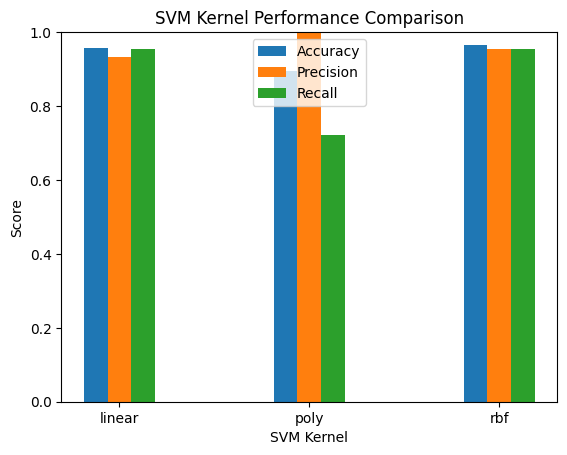

In [349]:
x = np.arange(len(kernels))
width = 0.125

plt.bar(
    x - width,
    accuracy_scores,
    width,
    label='Accuracy'
)

plt.bar(
    x,
    precision_scores,
    width,
    label='Precision'
)

plt.bar(
    x + width,
    recall_scores,
    width,
    label='Recall'
)

plt.xlabel("SVM Kernel")
plt.ylabel("Score")
plt.title("SVM Kernel Performance Comparison")

plt.xticks(x, kernels)
plt.ylim(0, 1)
plt.legend()

plt.show()

**confusion for Tuned RBF**

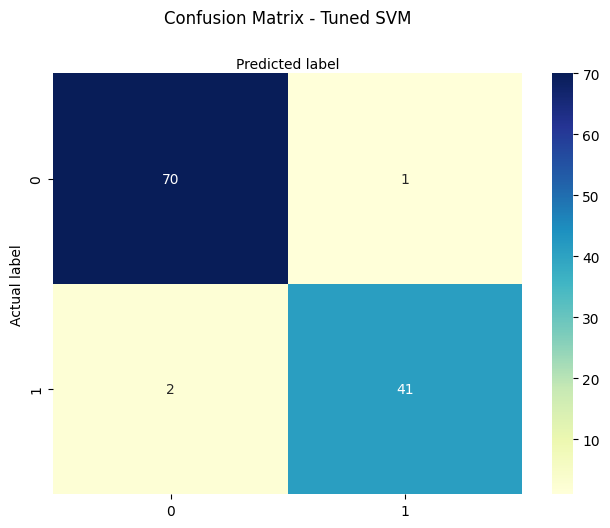

In [350]:
from sklearn.metrics import confusion_matrix

cnf_matrix = confusion_matrix(
    Y_test_Cancer,
    yfit
)

# Let's visualize the results of the model in the form of a
# confusion matrix using matplotlib and seaborn.

import seaborn as sns

class_names = [0, 1]   # 0 = Benign, 1 = Malignant

fig, ax = plt.subplots()

tick_marks = np.arange(len(class_names))

plt.xticks(tick_marks, class_names)
plt.yticks(tick_marks, class_names)

# create heatmap
sns.heatmap(
    pd.DataFrame(cnf_matrix),
    annot=True,
    cmap="YlGnBu",
    fmt='g'
)

ax.xaxis.set_label_position("top")

plt.tight_layout()

plt.title('Confusion Matrix - Tuned SVM', y=1.1)

plt.ylabel('Actual label')
plt.xlabel('Predicted label')

plt.show()


**Problem 2**

**Housing data**

In [351]:
#input dara link
url = 'https://raw.githubusercontent.com/iperezv-cpu/ML/refs/heads/main/Housing.csv'

housing = pd.read_csv(url)

# Display the first 10 rows of the DataFrame
housing.head()

,price,area,bedrooms,bathrooms,stories,mainroad,guestroom,basement,hotwaterheating,airconditioning,parking,prefarea,furnishingstatus
0,13300000,7420,4,2,3,yes,no,no,no,yes,2,yes,furnished
1,12250000,8960,4,4,4,yes,no,no,no,yes,3,no,furnished
2,12250000,9960,3,2,2,yes,no,yes,no,no,2,yes,semi-furnished
3,12215000,7500,4,2,2,yes,no,yes,no,yes,3,yes,furnished
4,11410000,7420,4,1,2,yes,yes,yes,no,yes,2,no,furnished


In [352]:
housing.shape

(545, 13)

**Null check**

In [353]:
# Checking Null values
housing.isnull().sum()*100/housing.shape[0]
# There are no NULL values in the dataset, hence it is clean.

,0
price,0.0
area,0.0
bedrooms,0.0
bathrooms,0.0
stories,0.0
mainroad,0.0
guestroom,0.0
basement,0.0
hotwaterheating,0.0
airconditioning,0.0


**Makes Yes and No to 1  and 0'S**

In [354]:
# List of variables to map

varlist =  ['mainroad', 'guestroom', 'basement', 'hotwaterheating', 'airconditioning', 'prefarea']

# Defining the map function
def binary_map(x):
    return x.map({'yes': 1, 'no': 0})

# Applying the function to the housing list
housing[varlist] = housing[varlist].apply(binary_map)
housing.head()


,price,area,bedrooms,bathrooms,stories,mainroad,guestroom,basement,hotwaterheating,airconditioning,parking,prefarea,furnishingstatus
0,13300000,7420,4,2,3,1,0,0,0,1,2,1,furnished
1,12250000,8960,4,4,4,1,0,0,0,1,3,0,furnished
2,12250000,9960,3,2,2,1,0,1,0,0,2,1,semi-furnished
3,12215000,7500,4,2,2,1,0,1,0,1,3,1,furnished
4,11410000,7420,4,1,2,1,1,1,0,1,2,0,furnished


**X and Y Definitions**

In [355]:
X = housing[
    ['area',
     'bedrooms',
     'bathrooms',
     'stories',
     'mainroad',
     'guestroom',
     'basement',
     'hotwaterheating',
     'airconditioning',
     'parking',
     'prefarea'

     ]
].values

y = housing['price'].values

In [356]:
print(X.shape)
print(y.shape)

(545, 11)
(545,)


**80/20 Split**

In [357]:
from sklearn.model_selection import train_test_split

# We specify this so that the train and test data set always have the same rows, respectively
np.random.seed(0)
X_train, X_test, y_train, y_test = train_test_split(X, Y, train_size = 0.8, test_size = 0.2, random_state = 42)

**Scaling**

In [358]:
#Here Scaling is important because there is a huge difference between all the features
from sklearn.preprocessing import StandardScaler   #import

# Separate scalers for X and y
sc_X = StandardScaler()
sc_y = StandardScaler()

X_train_scaled = sc_X.fit_transform(X_train)
X_test_scaled = sc_X.transform(X_test)

y_train_scaled = sc_y.fit_transform( y_train.reshape(-1, 1)).ravel()

y_test_scaled= sc_y.transform(y_test.reshape(-1, 1)).ravel()


In [359]:
print(X_train_scaled.shape)
print(X_test_scaled.shape)
print(y_train_scaled.shape)
print(y_test_scaled.shape)

(436, 11)
(109, 11)
(436,)
(109,)


**SVR**

In [360]:
# SVR Kernel Comparison Using Scaled Data

from sklearn.svm import SVR
from sklearn.metrics import r2_score
from sklearn.metrics import mean_absolute_error
from sklearn.metrics import mean_squared_error

kernels = ['linear', 'poly', 'rbf']

r2_scores = []
mae_scores = []
rmse_scores = []

for kernel in kernels:

    svr_model = SVR(
        kernel=kernel,
        C=1e3
    )

    # Train using scaled X and scaled y
    svr_model.fit(  X_train_scaled,  y_train_scaled)

    # Predict using scaled X test data
    y_pred_scaled = svr_model.predict( X_test_scaled )

    # Convert prediction back to original house-price units
    y_pred = sc_y.inverse_transform(y_pred_scaled.reshape(-1, 1)).ravel()

    # Evaluate against original y_test values
    r2_scores.append( r2_score(y_test, y_pred) )

    mae_scores.append( mean_absolute_error(y_test, y_pred) )

    rmse_scores.append( np.sqrt( mean_squared_error(y_test, y_pred)))


# Display results
for i in range(len(kernels)):

    print("Kernel:", kernels[i])
    print("R²:", r2_scores[i])
    print("MAE:", mae_scores[i])
    print("RMSE:", rmse_scores[i])
    print()

Kernel: linear
R²: 0.6177852616391267
MAE: 1000613.9379381189
RMSE: 1389939.295163296

Kernel: poly
R²: -1.404914070193429
MAE: 1907477.343476605
RMSE: 3486517.905339307

Kernel: rbf
R²: 0.21805107480801034
MAE: 1299599.125985031
RMSE: 1988068.3518049382



**regression Model**

In [361]:
import numpy as np
from sklearn.svm import SVR
import matplotlib.pyplot as plt

# Fit regression models using scaled training data


svr_rbf = SVR(kernel='rbf', C=1e3, gamma=0.1)
svr_lin = SVR(kernel='linear', C=1e3)
svr_poly = SVR(kernel='poly', C=1e3, degree=2)


# Train models using scaled X and scaled y
svr_rbf.fit(X_train_scaled, y_train_scaled)
svr_lin.fit(X_train_scaled, y_train_scaled)
svr_poly.fit(X_train_scaled, y_train_scaled)


# Predict using scaled X test data
y_rbf_scaled = svr_rbf.predict(X_test_scaled)
y_lin_scaled = svr_lin.predict(X_test_scaled)
y_poly_scaled = svr_poly.predict(X_test_scaled)



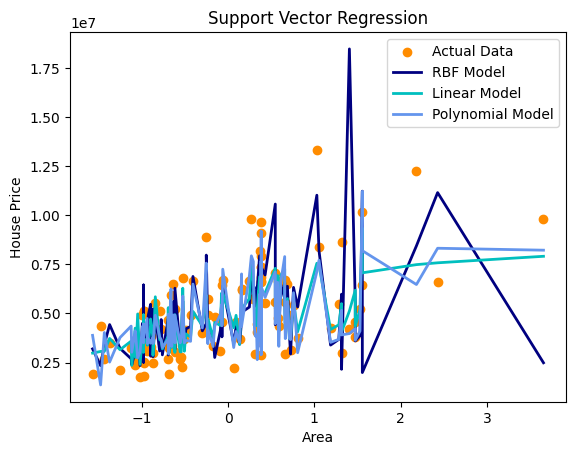

In [362]:

lw = 2

# Area is the first column of the original X_test data
area_test = X_test_scaled[:, 0]
# Sort by area so the model lines do not jump back and forth
sort_index = np.argsort(area_test)
area_sorted = area_test[sort_index]

y_rbf_sorted = y_rbf[sort_index]
y_lin_sorted = y_lin[sort_index]
y_poly_sorted = y_poly[sort_index]


# Actual test data
plt.scatter(area_test, y_test, color='darkorange', label='Actual Data')

# SVR predictions
plt.plot(area_sorted, y_rbf_sorted, color='navy', lw=lw, label='RBF Model')
plt.plot( area_sorted, y_lin_sorted, color='c', lw=lw, label='Linear Model')
plt.plot( area_sorted, y_poly_sorted, color='cornflowerblue', lw=lw, label='Polynomial Model')

plt.xlabel('Area')
plt.ylabel('House Price')
plt.title('Support Vector Regression')

plt.legend()
plt.show()

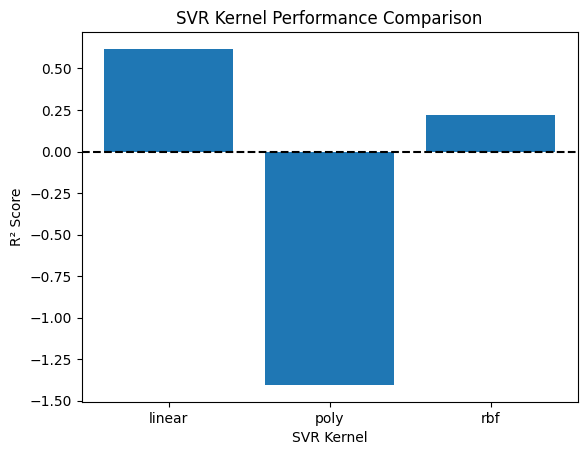

In [363]:
plt.bar(
    kernels,
    r2_scores
)

plt.xlabel('SVR Kernel')
plt.ylabel('R² Score')
plt.title('SVR Kernel Performance Comparison')

plt.axhline(
    y=0,
    color='black',
    linestyle='--'
)

plt.show()